In [1]:
import torch
import torch.nn as nn
import numpy as np
from model import LSTMClassifier

In [2]:
def predict(model, df, feature_cols, window=60, device="cpu"):
    """
    df: DataFrame с уже посчитанными фичами (те же, что при обучении!)
    Возвращает предсказание для ПОСЛЕДНЕГО окна в df
    """
    model.eval()
    model.to(device)
    
    features = df[feature_cols].values.astype(np.float32)
    
    if len(features) < window:
        raise ValueError(f"Недостаточно данных: нужно минимум {window} свечей, получено {len(features)}")
    
    x = features[-window:]  # last window
    
    if np.isnan(x).any() or np.isinf(x).any():
        raise ValueError(f"NaN/Inf в входных данных! NaN count: {np.isnan(x).sum()}, Inf count: {np.isinf(x).sum()}")
    
    x_tensor = torch.tensor(x).unsqueeze(0).to(device)  # batch dimension -> (1, window, n_features)
    
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = probs.argmax(dim=1).item()
    
    class_names = {0: "down", 1: "flat", 2: "up"}
    return {
        "prediction": class_names[pred_class],
        "probabilities": {
            "down": probs[0][0].item(),
            "flat": probs[0][1].item(),
            "up": probs[0][2].item()
        }
    }

In [3]:
import pandas as pd
from model import prepare_features_and_labels, feature_cols

# нужно заново создать модель с ТЕМИ ЖЕ параметрами архитектуры
model = LSTMClassifier(n_features=5, hidden_size=64, num_layers=2, num_classes=3)
model.load_state_dict(torch.load("models/lstm_0046_23.pt", map_location="cpu"))
model.eval()  # важно! переключает dropout/batchnorm в режим инференса

LSTMClassifier(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [2]:
import random
intervals = []

for i in range(100):
    random_hour = random.randint(0,10000)
    start = ( 1784365200-60*60*random_hour-60*90 )*1000
    end = ( 1784365200-60*60*random_hour )*1000
    intervals.append([start, end])
    
intervals = [[1773631800000, 1773637200000], [1774351800000, 1774357200000], [1773253800000, 1773259200000], [1765866600000, 1765872000000], [1759213800000, 1759219200000], [1754739000000, 1754744400000], [1770312600000, 1770318000000], [1755016200000, 1755021600000], [1770755400000, 1770760800000], [1778326200000, 1778331600000], [1782703800000, 1782709200000], [1750167000000, 1750172400000], [1773469800000, 1773475200000], [1752377400000, 1752382800000], [1783319400000, 1783324800000], [1763649000000, 1763654400000], [1750624200000, 1750629600000], [1781458200000, 1781463600000], [1758472200000, 1758477600000], [1773541800000, 1773547200000], [1764588600000, 1764594000000], [1761564600000, 1761570000000], [1776490200000, 1776495600000], [1768239000000, 1768244400000], [1756308600000, 1756314000000], [1773509400000, 1773514800000], [1764556200000, 1764561600000], [1784194200000, 1784199600000], [1773232200000, 1773237600000], [1766086200000, 1766091600000], [1750890600000, 1750896000000], [1759185000000, 1759190400000], [1749414600000, 1749420000000], [1771749000000, 1771754400000], [1770676200000, 1770681600000], [1766061000000, 1766066400000], [1783578600000, 1783584000000], [1775248200000, 1775253600000], [1769358600000, 1769364000000], [1750149000000, 1750154400000], [1749861000000, 1749866400000], [1774017000000, 1774022400000], [1763591400000, 1763596800000], [1766759400000, 1766764800000], [1759404600000, 1759410000000], [1750872600000, 1750878000000], [1775111400000, 1775116800000], [1768689000000, 1768694400000], [1768084200000, 1768089600000], [1749493800000, 1749499200000], [1751103000000, 1751108400000], [1783888200000, 1783893600000], [1767454200000, 1767459600000], [1770827400000, 1770832800000], [1756384200000, 1756389600000], [1757687400000, 1757692800000], [1774553400000, 1774558800000], [1763271000000, 1763276400000], [1775086200000, 1775091600000], [1773318600000, 1773324000000], [1777977000000, 1777982400000], [1755023400000, 1755028800000], [1779067800000, 1779073200000], [1773952200000, 1773957600000], [1783135800000, 1783141200000], [1779057000000, 1779062400000], [1748907000000, 1748912400000], [1777228200000, 1777233600000], [1749321000000, 1749326400000], [1777113000000, 1777118400000], [1777069800000, 1777075200000], [1780824600000, 1780830000000], [1782419400000, 1782424800000], [1766442600000, 1766448000000], [1773700200000, 1773705600000], [1761060600000, 1761066000000], [1753047000000, 1753052400000], [1752802200000, 1752807600000], [1758101400000, 1758106800000], [1751189400000, 1751194800000], [1774715400000, 1774720800000], [1771533000000, 1771538400000], [1772692200000, 1772697600000], [1759073400000, 1759078800000], [1767465000000, 1767470400000], [1778286600000, 1778292000000], [1754793000000, 1754798400000], [1774218600000, 1774224000000], [1775431800000, 1775437200000], [1775028600000, 1775034000000], [1760319000000, 1760324400000], [1781091000000, 1781096400000], [1756218600000, 1756224000000], [1751250600000, 1751256000000], [1772623800000, 1772629200000], [1771155000000, 1771160400000], [1760815800000, 1760821200000], [1762050600000, 1762056000000], [1771191000000, 1771196400000], [1765287000000, 1765292400000]]

win False, profit -55.4 points, ttl -55.4, winrate 0.0
win True, profit 81.0 points, ttl 25.6, winrate 0.5
win True, profit 38.1 points, ttl 63.7, winrate 0.667
win False, profit -1.2 points, ttl 62.5, winrate 0.5
win True, profit 31.9 points, ttl 94.4, winrate 0.6
win True, profit 98.1 points, ttl 192.5, winrate 0.667
win True, profit 25.8 points, ttl 218.3, winrate 0.714
win True, profit 31.7 points, ttl 250.0, winrate 0.75
win False, profit -122.8 points, ttl 127.2, winrate 0.667
win True, profit 33.5 points, ttl 160.7, winrate 0.7
win True, profit 284.8 points, ttl 445.5, winrate 0.727
win True, profit 93.5 points, ttl 539.0, winrate 0.75
win True, profit 116.5 points, ttl 655.5, winrate 0.769
win False, profit -105.0 points, ttl 550.5, winrate 0.714
win False, profit -39.6 points, ttl 510.9, winrate 0.667
win False, profit -71.8 points, ttl 439.1, winrate 0.625
win True, profit 61.7 points, ttl 500.8, winrate 0.647
win False, profit -42.3 points, ttl 458.5, winrate 0.611
win False

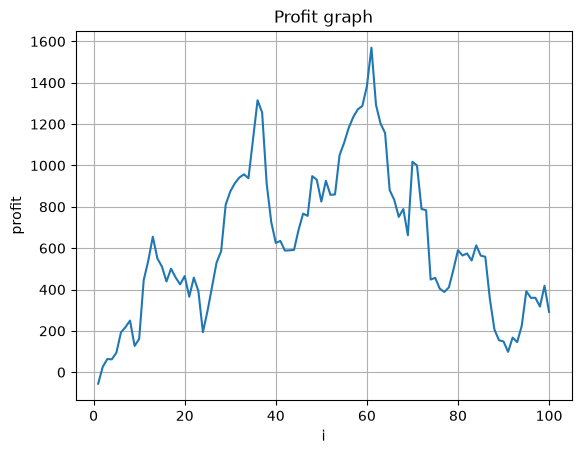

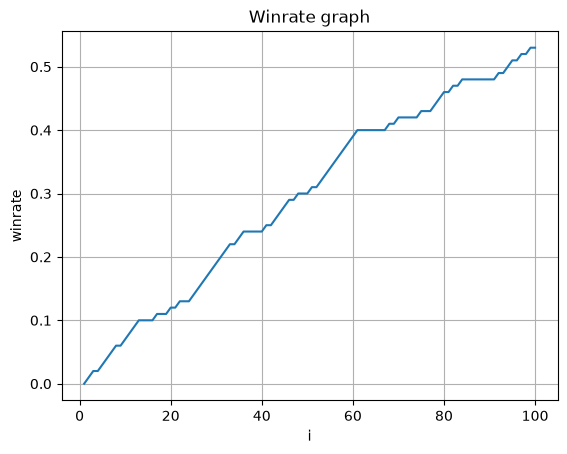

In [ ]:
from dataWorker import *
from datetime import datetime
from dataWorker import getOHLC
import matplotlib.pyplot as plt
# loading real data for test

profit_ttl = 0
wins = 0
profit_history = []
winrate_history = []
iters = 100
for i, interval in enumerate(intervals[:iters]):
    start = interval[0]
    end = interval[1]
    test_df = getOHLC('BTCUSDT', start, end, normalize=True)
    test_df = prepare_features_and_labels(test_df, horizon=5, flat_threshold=0.001) 
    #print(f"Selected interval from {datetime.fromtimestamp(start//1000)} to {datetime.fromtimestamp(end//1000)}")
    result = predict(model, test_df, feature_cols, window=5)
    #print(result)
    
    # collecting data from exchange
    df_plot = getOHLC('BTCUSDT', start, end)
    df_plot = df_plot.set_index("timestamp")
    df_final = getOHLC('BTCUSDT', (end//1000+60)*1000,(end//1000+60*5)*1000)
    df_final = df_final.set_index("timestamp")

    # calculate price change
    open_price = float(df_final.iloc[0]['open'])
    close_price = float(df_final.iloc[4]['close'])
    price_change = round(close_price - open_price, 3)
    
    if result.get('prediction') == 'down':
        profit = price_change * -1
    if result.get('prediction') == 'up':
        profit = price_change
        
    if profit>0: wins += 1
    profit_ttl += profit
    profit_ttl = round(profit_ttl, 2)
    print(f"win {profit>0}, profit {profit} points, ttl {profit_ttl}, winrate {round(wins/(i+1),3)}")
    
    profit_history.append(profit_ttl)
    winrate_history.append(round(wins/(i+1),3))
    

    # plotting
    # fig, ax = mpf.plot(df_plot, type='candle',returnfig=True, figsize = (10,5))
    # ax[0].set_title('Input Data')
    # fig,ax = mpf.plot(df_final, type='candle',returnfig=True, figsize = (10,5))
    # ax[0].set_title('Prediction Window')
    
print(f"Profit: {profit_ttl} points with winrate {round(wins/iters,2)}")    

fig, ax = plt.subplots()
t = np.arange(1,iters+1, 1)
ax.plot(t, profit_history)
ax.set(xlabel='i', ylabel='profit',
       title='Profit graph')
ax.grid()
plt.show()

fig, ax = plt.subplots()
ax.plot(t, winrate_history)
ax.set(xlabel='i', ylabel='winrate',
       title='Winrate graph')
ax.grid()
plt.show()

In [ ]:
# from dataWorker import getOHLC
# import mplfinance as mpf

# df_plot = getOHLC('BTCUSDT', start, end)
# df_plot = df_plot.set_index("timestamp")
# df_final = getOHLC('BTCUSDT', (end//1000+60)*1000,(end//1000+60*5)*1000)
# df_final = df_final.set_index("timestamp")

# open_price = float(df_final.iloc[0]['open'])
# close_price = float(df_final.iloc[4]['close'])

# profit = round(close_price - open_price, 3)
# if result.get('prediction') == 'down':
#     if profit < 0: print(f'win {abs(profit)} points')
#     else: print(f'loss {abs(profit)} points')
# if result.get('prediction') == 'up':
#     if profit > 0: print(f'win {abs(profit)} points')
#     else: print(f'loss {abs(profit)} points')

# # plotting
# fig, ax = mpf.plot(df_plot, type='candle', returnfig=True, figsize = (10,5))
# ax[0].set_title('Input Data')
# fig,ax = mpf.plot(df_final, type='candle', returnfig=True, figsize = (10,5))
# ax[0].set_title('Prediction Window')

: 